In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [316]:
dt = '2026-02-06'

In [440]:
def test(dt):
    ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')
    min_dist = list()
    for i in range(23):
        trades = pd.read_parquet(f'data/raw/amberdata/market_data/spot/trades/binance/{dt}/eth_usdt_T{0+i:02d}00.parquet')
        min_dist.append(to_trade_dist(trades))
    min_dist = pd.concat(min_dist)
    #dist_sse = (min_dist.sub(min_dist.mean(axis=0), axis=1).div(min_dist.std(axis=0), axis=1)).mean(axis=1).reset_index(drop=True)
    dist_sse = (min_dist.sub(min_dist.mean(axis=0), axis=1)**2).sum(axis=1).reset_index(drop=True)
    dist_sse.name = 'dist_sse'
    dist_sse.plot()
    return
    full_df = ohlcv_1m.copy()
    full_df = full_df.merge(dist_sse, on='exchangeTimestamp', how='left')
    full_df['return'] = np.log(full_df['close']).diff(5)
    full_df['return_fwd'] = np.log(full_df['close']).diff(5).shift(-5)
    full_df['bins'] = pd.qcut(full_df['dist_sse'], q=10)
    #full_df['bins'] = pd.cut(full_df['dist_sse'], bins=10)
    #full_df.groupby('bins')['return_fwd'].mean().plot(kind='bar')
    full_df.groupby('bins').apply(lambda g: g['return_fwd'].corr(g['return'])).plot(kind='bar',alpha=0.1)
    #full_df.groupby('bins').count()

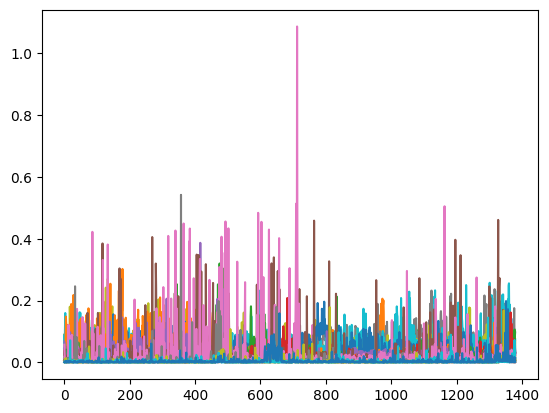

In [441]:

for dt in ['2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21', '2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26'][:]:
    test(dt)


In [318]:
def leading_digit(x):
    s = str(x).replace(".", "")      # remove decimal point
    s = s.lstrip("0")      # remove leading zeros
    return s[0]

In [319]:
def ceil_to_minute_seconds(ts: int | float) -> int:
    return int(math.ceil(ts / 60000) * 60000)
def floor_to_minute_seconds(ts: int | float) -> int:
    return int(math.floor(ts / 60000) * 60000)

In [432]:
def to_trade_dist(df):
    df = df.copy()
    df['dollar_volume'] = df['volume'] * df['price']
    df['leading_digit'] = df['dollar_volume'].map(leading_digit)
    df['exchangeTimestamp'] = df['exchangeTimestamp'].map(floor_to_minute_seconds)
    df_dist = df[['exchangeTimestamp', 'leading_digit']].pivot_table(index='exchangeTimestamp', columns='leading_digit', aggfunc='size')
    df_dist = df_dist.div(df_dist.sum(axis=1), axis=0)
    #df_sse = (df_dist.sub(df_dist.mean(axis=0), axis=1)**2).sum(axis=1)
    return df_dist

In [360]:
def to_noise_frac(df):
    df = df.copy()
    df['dollar_volume'] = df['volume'] * df['price']
    df['exchangeTimestamp'] = df['exchangeTimestamp'].map(floor_to_minute_seconds)
    df_noise = df[['exchangeTimestamp', 'leading_digit']].pivot_table(index='exchangeTimestamp', columns='leading_digit', aggfunc='size')
    df_noise = df_noise.div(df_noise.sum(axis=1), axis=0)
    return df_noise

In [406]:
dt = '2026-02-02'

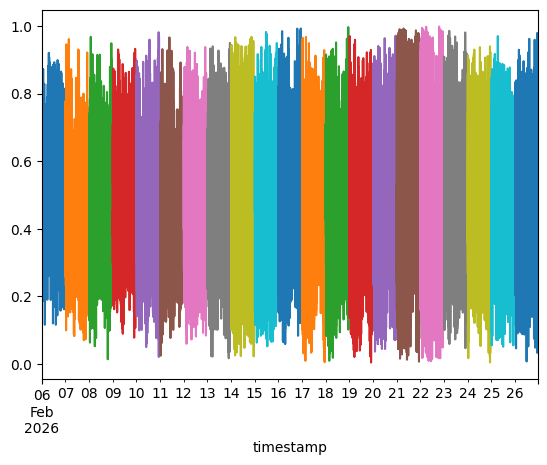

In [426]:
corrs = list()
for dt in ['2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21', '2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26']:
    ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')
    ohlcv_1m['timestamp'] = pd.to_datetime(ohlcv_1m['exchangeTimestamp'],unit='ms')
    ohlcv_1m.set_index('timestamp',inplace=True)

    trades_list = list()
    for i in range(23):
        trades = pd.read_parquet(f'data/raw/amberdata/market_data/spot/trades/binance/{dt}/eth_usdt_T{0+i:02d}00.parquet')
        trades['dollar_volume'] = trades['volume'] * trades['price']
        trades_list.append(trades)
    trades = pd.concat(trades_list)
    trades = trades.sort_values(by='tradeId')
    trades['timestamp'] = pd.to_datetime(trades['exchangeTimestamp'],unit='ms')
    trades.set_index('timestamp',inplace=True)
    trades['buy'] = trades['isBuySide'] * trades['dollar_volume']
    agg_trades = trades.resample('1min').agg(
        {
            'dollar_volume': 'sum',
            'buy': 'sum'
        }
    )
    agg_trades['buy_frac'] = agg_trades['buy'].div(agg_trades['dollar_volume'])
    agg_trades['buy_frac'].plot()
    full_df = agg_trades.merge(ohlcv_1m, on='timestamp', how='left')
    full_df['return'] = np.log(full_df['close']).diff().shift(-1)
    full_df['bin'] = pd.qcut(full_df['dollar_volume'],q=10,labels=range(10))
    corr_by_group = full_df.groupby("bin").apply(lambda g: g["buy_frac"].corr(g["return"]))
    corr_by_group.name = dt
    corrs.append(corr_by_group)

<Axes: xlabel='bin'>

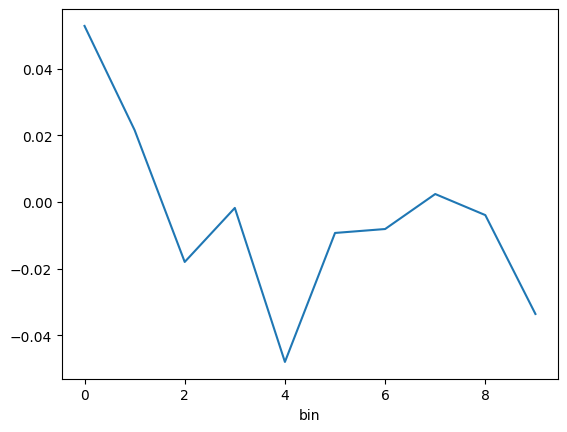

In [429]:
corrs_df = pd.concat(corrs,axis=1)
corrs_df.mean(axis=1).plot()